<a href="https://colab.research.google.com/github/lucmos2002/workshopGITHUB/blob/master/tp3_rnn_Lucas_Souza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP3: Redes Neurais Recorrentes (RNNs)**

### **Introdução**
Neste projeto prático, você implementará uma rede neural recorrente (RNN) em PyTorch para **gerar nomes de dinossauros** usando um modelo de linguagem em nível de caractere. Primeiro, você criará uma classe para carregar o conjunto de dados. Em seguida, você construirá uma RNN tradicional. Depois, você treinará essa rede usando **gradiente descendente em mini-lotes** (*mini-batch gradient descent*). Por fim, você utilizará o modelo treinado para **gerar novos nomes de dinossauros**.

### **Objetivo**

O principal objetivo deste projeto é **praticar a implementação de RNNs em PyTorch**, incluindo:
- carregamento de conjuntos de dados,
- implementação de camadas personalizadas,
- treinamento com gradiente descendente,
- e geração de texto com modelos de linguagem.

### **Instruções**

Após cada célula desse tipo, há uma **célula de teste** seguida dos **resultados esperados**, para que você possa verificar se sua solução está correta.  Seus resultados podem ser ligeiramente diferentes dos esperados e ainda assim estarem corretos.

### **Parte 0: Importar bibliotecas**

Assim como nos trabalhos anteriores, você importará a biblioteca `torch` e outras bibliotecas auxiliares.

In [34]:
import torch
import sys
import random

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

### **Parte 1: Carregamento e pré-processamento do conjunto de dados**

Nesta primeira parte, você fará o download do conjunto de dados em um arquivo de texto (`dinos.txt`), que contém **nomes de 1536 dinossauros**. Cada nome está separado por um caractere `\n`.

In [35]:
!wget -O 'dinos.txt' 'https://lucasnfe.github.io/ufv-inf721/static_files/datasets/p5-rnn/dinos.txt'

--2026-09-17 17:29:35--  https://lucasnfe.github.io/ufv-inf721/static_files/datasets/p5-rnn/dinos.txt
Resolving lucasnfe.github.io (lucasnfe.github.io)... 185.199.108.153, 185.199.110.153, 185.199.111.153, ...
Connecting to lucasnfe.github.io (lucasnfe.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19910 (19K) [text/plain]
Saving to: ‘dinos.txt’

dinos.txt           100%[===================>]  19.44K  --.-KB/s    in 0.002s  

2026-09-17 17:29:35 (11.5 MB/s) - ‘dinos.txt’ saved [19910/19910]



#### **1.1 Baixar os dados e criar o vocabulário**

Leia o arquivo `'dinos.txt'` para carregar todos os nomes de dinossauros em uma lista e produza os conjuntos de **treinamento e teste** de forma aleatória usando uma divisão de **80/20**.  

Além disso, crie um **vocabulário** (lista) com todos os caracteres presentes no arquivo de texto, **ordenados alfabeticamente**.  

Certifique-se de incluir **três caracteres de controle adicionais** em seu vocabulário:
- `'['` → **SOS** (*Start of Sequence*, início da sequência)  
- `']'` → **EOS** (*End of Sequence*, fim da sequência)  
- `'@'` → **padding** (preenchimento)

In [36]:
# Define a semente para reprodutibilidade
random.seed(42)

# Caminho do arquivo de texto com os nomes dos dinossauros
file_path = "dinos.txt"
with open(file_path, 'r') as file:
  raw_text = file.read()

# Embaralha os nomes
names = raw_text.split('\n')
random.shuffle(names)

# Divide o conjunto de dados aleatoriamente em 80% treino e 20% teste
train_size = int(0.8 * len(names))
train_text = names[:train_size]
test_text = names[train_size:]

# Cria o vocabulário a partir do texto bruto e adiciona os caracteres de controle
vocab = sorted(list(set(raw_text) | {'[', ']', '@'}))

# Exibe exemplos e informações
print("Primeiros 5 exemplos de treino:", train_text[:5])
print("Primeiros 5 exemplos de teste:", test_text[:5])
print("10 primeiros caracteres do vocabulário:", vocab[:10])
print("Tamanho do vocabulário:", len(vocab))

Primeiros 5 exemplos de treino: ['Antetonitrus', 'Tienshanosaurus', 'Helopus', 'Albertosaurus', 'Helioceratops']
Primeiros 5 exemplos de teste: ['Spondylosoma', 'Proyandusaurus', 'Sarcosaurus', 'Arcovenator', 'Elvisaurus']
10 primeiros caracteres do vocabulário: ['\n', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
Tamanho do vocabulário: 56


**Resultado esperado**:

<table style="width:50%">
  <tr>
    <td> Primeiros 5 exemplos de treino </td>
    <td>['Antetonitrus', 'Tienshanosaurus', 'Helopus', 'Albertosaurus', 'Helioceratops']</td>
  </tr>
  <tr>
    <td> Primeiros 5 exemplos de teste </td>
    <td>['Spondylosoma', 'Proyandusaurus', 'Sarcosaurus', 'Arcovenator', 'Elvisaurus']</td>
  </tr>
  <tr>
    <td> 10 primeiros caracteres do vocabulário </td>
    <td>['\n', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']</td>
  </tr>
  <tr>
    <td> Tamanho do vocabulário </td>
    <td> 65</td>
  </tr>
</table>

#### **1.2 Criar uma classe Dataset para armazenar o conjunto de dados**

O PyTorch fornece a classe [`torch.utils.data.Dataset`](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) para carregar conjuntos de dados a partir de arquivos.  
Para criar um **conjunto de dados personalizado**, você precisa **estender** a classe `Dataset` e implementar três funções principais: `__init__`, `__len__` e `__getitem__`.  

Nesta etapa, você implementará essas três funções e algumas funções auxiliares para construir um **dataset para o modelo de linguagem de nomes de dinossauros**.

---

- `__init__`:  
  Inicializa o dataset criando atributos para armazenar os nomes e o vocabulário. Adicione os tokens **SOS** (`[`) e **EOS** (`]`) a cada nome antes de armazená-los.  Além disso, crie **mapeamentos entre caracteres e índices** e vice-versa. É útil também calcular e armazenar o **comprimento máximo de uma palavra** no conjunto de dados.

- `one_hot_encode(ix)`:  
  Cria um **vetor one-hot** (codificado em uma única posição 1) para um determinado índice.

- `encode(seq_ch)`:  
  Converte uma **sequência de caracteres** em um **tensor de vetores one-hot**.

- `decode(seq_ix)`:  
  Converte uma **sequência de índices** de volta para uma **string de caracteres**.

- `__len__`:  
  Retorna o **número total de sequências** no conjunto de dados.

- `__getitem__(index)`:  
  Processa um único nome de dinossauro aplicando **padding** (com o caractere `@`) para igualar o comprimento da sequência mais longa, e retorna os **pares de tensores de entrada e saída**. Use `torch.tensor()` para converter a sequência de saída em um tensor.

---

💡 **Lembre-se:**  
Em modelagem de linguagem, suas **sequências de entrada (`x`)** devem estar **deslocadas por um caractere** em relação às **sequências-alvo (`y`)**,  permitindo que o modelo **aprenda a prever o próximo caractere** da sequência.

In [37]:
class DinosDataset(Dataset):
    def __init__(self, names, vocab):
      # Cria o vocabulário de caracteres
      self.vocab = vocab
      self.ch2ix = dict(zip(vocab, range(len(vocab))))
      self.ix2ch = dict(zip(range(len(vocab)), vocab))

      # Cria as amostras adicionando os tokens SOS e EOS
      self.sequences = []
      for name in names:
        self.sequences.append(f'[{name}]')
      self.max_len = len(max(names, key=len)) + 2


    def one_hot_encode(self, ix):
      """
      Cria um tensor one-hot para um determinado índice.

      Args:
          ix (int): Índice a ser codificado.

      Retorna:
          torch.Tensor: Um tensor one-hot de formato (vocab_size).
      """
      one_hot = torch.zeros(len(self.vocab))
      one_hot[ix] = 1.0
      return one_hot
      ######################################
      # SEU CÓDIGO AQUI (remova o pass)
      ######################################

    def encode(self, seq_ch):
      """
      Converte uma sequência de caracteres em um tensor de vetores one-hot.

      Args:
          seq_ch (str): String representando a sequência de caracteres a ser codificada.

      Retorna:
          torch.Tensor: Tensor de vetores one-hot representando a sequência de entrada.
      """
      seq_ix = [self.ch2ix[ch] for ch in seq_ch]
      seq_vec = torch.stack([self.one_hot_encode(ix) for ix in seq_ix])
      return seq_vec
      ######################################
      # SEU CÓDIGO AQUI (remova o pass)
      ######################################

    def decode(self, seq_ix):
      """
      Converte uma sequência de índices de volta em uma string de caracteres.

      Args:
          seq_ix (list): Lista de índices representando os caracteres da sequência.

      Retorna:
          str: String decodificada de caracteres.
      """
      ix2ch = {ix: ch for ch, ix in self.ch2ix.items()}
      return ''.join([ix2ch[ix] for ix in seq_ix])
      ######################################
      # SEU CÓDIGO AQUI (remova o pass)
      ######################################

    def __len__(self):
      """
      Retorna o número total de sequências no conjunto de dados.

      Retorna:
          int: Total de sequências no dataset.
      """
      return len(self.sequences)
      ######################################
      # SEU CÓDIGO AQUI (remova o pass)
      ######################################

    def __getitem__(self, index):
      """
      Obtém uma única amostra do conjunto de dados.

      Args:
          index (int): Índice da amostra a ser recuperada.

      Retorna:
          tuple: Um par contendo o tensor de entrada x e o tensor-alvo y.
      """
      sample = self.sequences[index]
      pad_len = self.max_len - len(sample)
      sample += ('@' * pad_len)
      x = sample[:-1]
      y = sample[1:]
      return self.encode(x), torch.tensor([self.ch2ix[ch] for ch in y])
      ######################################
      # SEU CÓDIGO AQUI (remova o pass)
      ######################################

    @property
    def vocab_size(self):
      """
      Retorna o tamanho do vocabulário.

      Retorna:
          int: Tamanho do vocabulário.
      """
      return len(self.vocab)

In [38]:
# Cria os conjuntos de dados de treino e teste
train_dataset = DinosDataset(train_text, vocab)
test_dataset = DinosDataset(test_text, vocab)

# Exibe informações gerais sobre o vocabulário e os conjuntos de dados
print("Tamanho do vocabulário (treino):", train_dataset.vocab_size)
print("Tamanho do vocabulário (teste):", test_dataset.vocab_size)

print("Comprimento máximo das sequências (treino):", train_dataset.max_len)
print("Comprimento máximo das sequências (teste):", test_dataset.max_len)

print("Tamanho do conjunto de treino:", len(train_dataset))
print("Tamanho do conjunto de teste:", len(test_dataset))

Tamanho do vocabulário (treino): 56
Tamanho do vocabulário (teste): 56
Comprimento máximo das sequências (treino): 28
Comprimento máximo das sequências (teste): 21
Tamanho do conjunto de treino: 1229
Tamanho do conjunto de teste: 308


**Resultado esperado**:

<table style="width:50%">
  <tr>
    <td> Tamanho do vocabulário (treino) </td>
    <td>56</td>
  </tr>
  <tr>
    <td> Tamanho do vocabulário (teste) </td>
    <td>56</td>
  </tr>
  <tr>
    <td> Comprimento máximo das sequências (treino) </td>
    <td>28</td>
  </tr>
  <tr>
    <td> Comprimento máximo das sequências (teste) </td>
    <td>21</td>
  </tr>
  <tr>
    <td> Tamanho do conjunto de treino </td>
    <td>1229</td>
  </tr>
  <tr>
    <td> Tamanho do conjunto de teste </td>
    <td>308</td>
  </tr>
</table>

#### **1.3 Visualização de exemplos**

Se você carregou os dados corretamente, pode usar o código abaixo para **visualizar exemplos do conjunto de dados**.

In [39]:
# Seleciona o primeiro exemplo do conjunto de treino
x = train_dataset.sequences[0]
x_encoded, y = train_dataset[0]

# Exibe o nome original, o tamanho do tensor codificado e a sequência alvo
print("x0:", x)
print("tamanho de x0_codificado:", x_encoded.size())
print("y:", y)

x0: [Antetonitrus]
tamanho de x0_codificado: torch.Size([27, 56])
y: tensor([ 2, 43, 49, 34, 49, 44, 43, 38, 49, 47, 50, 48, 29,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1])


**Resultado esperado**:

<table style="width:50%">
  <tr>
    <td>x0</td>
    <td>[Antetonitrus]</td>
  </tr>
  <tr>
    <td>tamanho de x0 codificado</td>
    <td>[27, 56]</td>
  </tr>
  <tr>
    <td>y</td>
    <td>[2, 43, 49, 34, 49, 44, 43, 38, 49, 47, 50, 48, 29,  1,  1,  1,  1,  1,
         1,  1,  1,  1,  1,  1,  1,  1,  1]</td>
  </tr>
</table>

#### **1.4 Criar um DataLoader para iterar pelos exemplos**

Crie um `train_loader` e um `test_loader` usando o [DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) do PyTorch para os conjuntos de **treinamento** e **teste**.  

Configure ambos com os seguintes parâmetros:
- `batch_size = 32`
- `drop_last = True` (para remover o último mini-lote caso ele esteja incompleto)

Certifique-se de definir o parâmetro `shuffle=True` no **DataLoader de treinamento**. Você **não precisa embaralhar** os dados no **DataLoader de teste**.

In [40]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [41]:
############################################################################
# SEU CÓDIGO AQUI (substitura os Nones pela função DataLoader)
############################################################################
train_loader = DataLoader(train_dataset, batch_size=32, drop_last=True, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, drop_last=True, shuffle=False)

In [42]:
torch.manual_seed(1)

# Pressupõe que as variáveis train_loader e test_loader foram definidas na célula anterior.
train_x_batch, train_y_batch = next(iter(train_loader))
test_x_batch, test_y_batch = next(iter(test_loader))

print("Tamanho de um único lote de treino:", train_x_batch.size())
print("Tamanho de um único lote de teste:", test_x_batch.size())

print("Verificação rápida (treino):", train_x_batch[0][1])
print("Verificação rápida (teste):", test_x_batch[0][1])

Tamanho de um único lote de treino: torch.Size([32, 27, 56])
Tamanho de um único lote de teste: torch.Size([32, 20, 56])
Verificação rápida (treino): tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.])
Verificação rápida (teste): tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.])


**Resultado esperado**:

<table style="width:50%">
  <tr>
    <td> Tamanho de um único lote de treino </td>
    <td>[32, 27, 56]</td>
  </tr>
  <tr>
    <td> Tamanho de um único lote de teste </td>
    <td>[32, 20, 56]</td>
  </tr>
  <tr>
    <td> Verificação rápida (treino) </td>
    <td>[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]
    </td>
  </tr>
  <tr>
    <td> Verificação rápida (teste) </td>
    <td>[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]
    </td>
  </tr>
</table>

## **Parte 2: Rede Neural Recorrente (RNN)**

Agora que você já tem um conjunto de dados pronto para o treinamento, é hora de **criar sua RNN**.

#### **2.1 Camada Recorrente (Recurrent Hidden Layer)**

O primeiro passo para criar sua RNN é implementar uma classe que **estenda `torch.nn.Module`**, com:
- um método `__init__` para **inicializar os pesos da RNN**, e  
- um método `forward(x)` para **propagar a entrada pela rede**.

---

- **Inicialização dos pesos (`__init__`)**:  
  Use [`torch.nn.Parameter`](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html) para inicializar os pesos da RNN:
  - `self.Wx`: pesos das entradas  
  - `self.Wh`: pesos do estado oculto  
  - `self.b`: viés (*bias*)  

  Inicialize os pesos com **valores aleatórios pequenos** (`torch.randn * 0.01`)  
  e o viés com **zeros** (`torch.zeros`).

---

- **Propagação direta (*Forward propagation*) (`forward(x)`)**:  
  Implemente o passo de propagação da RNN (apenas para a **camada oculta**) seguindo a equação:

  \[
    h^{<t>} = \tanh(W_{h} h^{<t-1>} + W_{x}x^{<t>} + b)
  \]

  onde:  
  - \( x_t \): entrada no tempo *t*  
  - \( h_t \): estado oculto no tempo *t*  
  - \( W_x, W_h, b \): parâmetros treináveis da rede

---

**Lembre-se de:**
1. Tratar o caso do **estado oculto inicial** (geralmente um vetor de zeros)  
2. Processar a sequência de entrada **da esquerda para a direita**  
3. Usar `torch.cat` para **concatenar os estados ocultos** ao longo do tempo  
4. Usar `permute` para organizar o tensor de saída no formato  
   **(batch_size, seq_len, hidden_size)**

In [43]:
class DinosRNNLayer(torch.nn.Module):
    def __init__(self, input_size, hidden_size):
        """
        Inicializa a camada RNN.

        Args:
            input_size (int): Número de features esperadas na entrada x.
            hidden_size (int): Número de features no estado oculto h.
        """
        super(DinosRNNLayer, self).__init__()
        self.Wx = torch.nn.Parameter(torch.randn(hidden_size, input_size) * 0.01)
        self.Wh = torch.nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b = torch.nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x, h_prev):
        """
        Passagem direta (forward) da RNN.

        Args:
            x (torch.Tensor): Tensor de entrada de formato (batch_size, sequence_length, input_size).
            h_prev (torch.Tensor): Estado oculto inicial de formato (batch_size, hidden_size).

        Retorna:
            outputs (torch.Tensor): Sequência de estados ocultos ao longo do tempo.
            h_t (torch.Tensor): Estado oculto final após processar toda a sequência x.
        """
        batch_size, sequence_length, _ = x.size()
        hidden_size = self.Wh.size(0)

        # Initialize hidden state h_t if not provided
        # h_t will be (batch_size, hidden_size)
        h_t = torch.zeros(batch_size, hidden_size).to(x.device) if h_prev is None else h_prev

        outputs = []
        for t in range(sequence_length):
            x_t = x[:, t, :]  # Input at time step t: (batch_size, input_size)

            # Apply the RNN recurrence: h_t = tanh(W_h h_{t-1} + W_x x_t + b)
            # Wx is (hidden_size, input_size)
            # Wh is (hidden_size, hidden_size)
            # x_t is (batch_size, input_size)
            # h_t (previous) is (batch_size, hidden_size)

            # For W_x x_t: we need (batch_size, input_size) @ (input_size, hidden_size)
            # So, x_t @ Wx.T will work: (batch_size, input_size) @ (input_size, hidden_size) -> (batch_size, hidden_size)
            term_x = torch.matmul(x_t, self.Wx.T)

            # For W_h h_{t-1}: we need (batch_size, hidden_size) @ (hidden_size, hidden_size)
            # So, h_t @ Wh.T will work: (batch_size, hidden_size) @ (hidden_size, hidden_size) -> (batch_size, hidden_size)
            term_h = torch.matmul(h_t, self.Wh.T)

            h_t = torch.tanh(term_h + term_x + self.b)
            outputs.append(h_t)

        # The outputs list contains tensors of shape (batch_size, hidden_size) for each time step.
        # torch.stack(outputs) will give (sequence_length, batch_size, hidden_size).
        # We need to permute it to (batch_size, sequence_length, hidden_size) as specified in the problem description.
        outputs_stacked = torch.stack(outputs).permute(1, 0, 2)
        return outputs_stacked, h_t

In [44]:
torch.manual_seed(1)

# Cria uma camada RNN simples com 10 unidades ocultas
rnn_layer = DinosRNNLayer(input_size=train_dataset.vocab_size, hidden_size=10)

# Seleciona o primeiro exemplo do conjunto de treino
x, y = train_dataset[0]

# Desativa o cálculo de gradientes para teste da camada
with torch.no_grad():
  outputs, hidden = rnn_layer(x.unsqueeze(0), None)

# Exibe os resultados
print("Tamanho da saída:", outputs.size())
print("Último estado oculto:", hidden)

Tamanho da saída: torch.Size([1, 27, 10])
Último estado oculto: tensor([[-0.0080,  0.0096, -0.0057,  0.0152, -0.0048, -0.0194, -0.0054,  0.0190,
          0.0019,  0.0076]])


**Resultado esperado**:

<table style="width:50%">
  <tr>
    <td> **Tamanho da saída** </td>
    <td>[1, 27, 10]</td>
  </tr>
  <tr>
    <td> **Último estado oculto** </td>
    <td>[[[-0.0080,  0.0096, -0.0057,  0.0152, -0.0048, -0.0194, -0.0054,
           0.0190,  0.0019,  0.0076]]]</td>
  </tr>
</table>

#### **2.2 Modelo de Linguagem**

Use sua camada recorrente para **definir o modelo de linguagem**.  
Estenda `torch.nn.Module` para criar um modelo capaz de **prever o próximo caractere** em uma sequência.

---

Seu modelo deve conter:
- Uma **camada recorrente** (da implementação anterior)  
- Uma **camada totalmente conectada** (`torch.nn.Linear`)

---

A arquitetura deve:
1. Receber **caracteres codificados em one-hot** (tamanho igual ao vocabulário)  
2. Processá-los pela **camada RNN** (gerando os estados ocultos)  
3. Passar os estados ocultos por uma **camada linear** para prever o próximo caractere  
4. Retornar **as previsões** e o **estado oculto final**

---

💡 **Lembre-se:**  
A camada linear deve **processar a saída da RNN em cada passo de tempo**, para gerar previsões de caracteres a cada posição da sequência.

---

**Parâmetros:**
- **Tamanho de entrada:** `vocab_size`  
- **Tamanho do estado oculto:** definido pelo parâmetro `hidden_size`  
- **Tamanho da saída:** `vocab_size` (para prever as probabilidades de cada caractere possível)

In [45]:
class DinosRNNLanguageModel(torch.nn.Module):
    def __init__(self, vocab_size, hidden_size):
        """
        Inicializa o modelo de linguagem baseado em RNN.

        Args:
            vocab_size (int): Tamanho do vocabulário (número de caracteres possíveis).
            hidden_size (int): Número de unidades no estado oculto da RNN.
        """
        super(DinosRNNLanguageModel, self).__init__()
        self.rnn_layer = DinosRNNLayer(input_size=vocab_size, hidden_size=hidden_size)
        self.fc = torch.nn.Linear(hidden_size, vocab_size)

        ######################################
        # SEU CÓDIGO AQUI (remova o pass)
        ######################################

    def forward(self, x, hidden):
        """
        Passagem direta do modelo de linguagem.

        Args:
            x (torch.Tensor): Tensor de entrada no formato (batch_size, seq_len, vocab_size)
            hidden (torch.Tensor): Estado oculto inicial (batch_size, hidden_size)

        Retorna:
            outputs (torch.Tensor): Saída do modelo com previsões para cada caractere
            hidden (torch.Tensor): Estado oculto final da sequência
        """
        # Pass the input through the RNN layer
        rnn_outputs, hidden = self.rnn_layer(x, hidden)

        # Apply the linear layer to the RNN outputs to get predictions
        # rnn_outputs has shape (batch_size, seq_len, hidden_size)
        # We want to apply fc to each time step, so reshape or apply directly
        # Since fc expects (..., hidden_size), applying it directly will work
        # and return (batch_size, seq_len, vocab_size)
        outputs = self.fc(rnn_outputs)

        return outputs, hidden

        ######################################
        # SEU CÓDIGO AQUI (remova o pass)
        ######################################

In [46]:
torch.manual_seed(1)

# Seleciona o primeiro exemplo do conjunto de treino
x, y = train_dataset[0]

# Cria o modelo de linguagem baseado em RNN
language_model = DinosRNNLanguageModel(vocab_size=train_dataset.vocab_size, hidden_size=10)

# Executa uma passagem direta sem cálculo de gradientes
with torch.no_grad():
  outputs, hidden = language_model(x.unsqueeze(0), None)

# Exibe o tamanho da saída e o estado oculto final
print("Tamanho da saída:", outputs.size())
print("Estado oculto:", hidden)

Tamanho da saída: torch.Size([1, 27, 56])
Estado oculto: tensor([[-0.0080,  0.0096, -0.0057,  0.0152, -0.0048, -0.0194, -0.0054,  0.0190,
          0.0019,  0.0076]])


**Resultado esperado**:

<table style="width:50%">
  <tr>
    <td> Tamanho da saída </td>
    <td>[1, 27, 56]</td>
  </tr>
  <tr>
    <td> Estado oculto </td>
    <td>[[[-0.0080,  0.0096, -0.0057,  0.0152, -0.0048, -0.0194, -0.0054,
           0.0190,  0.0019,  0.0076]]]</td>
  </tr>
</table>

## **Parte 3: Treinamento com Gradiente Descendente em Mini-lotes**

Na terceira etapa, você escreverá o **loop de treinamento** para o seu modelo de linguagem que gera nomes de dinossauros.

---

#### **3.1 Calcular a perda (*loss*) no conjunto de teste**

Antes de escrever o loop de treinamento, você precisará implementar uma função para **calcular a perda no conjunto de teste**,  
de modo a registrar o erro de teste ao longo das épocas de treinamento.

Para calcular a perda:
1. Execute a **passagem direta (forward pass)** para cada mini-lote do conjunto de teste.  
2. **Some as perdas** obtidas em cada mini-lote.  
3. Retorne a **perda média**, dividindo essa soma pelo número total de mini-lotes do conjunto de teste.

In [47]:
def test(model, test_loader):
  """
  Avalia um modelo em um conjunto de dados armazenado em um DataLoader.

  Argumentos:
  - model (torch.nn.Module): Modelo de linguagem a ser avaliado.
  - test_loader (torch.utils.data.DataLoader): DataLoader para o conjunto de teste.
  """
  # 1. Coloca o modelo em modo de avaliação
  model.eval()
  test_loss = 0.0
  total_samples = 0
  criterion = torch.nn.CrossEntropyLoss()

  # 2. Desativa o cálculo de gradientes
  with torch.no_grad():
    for inputs, targets in test_loader:
        # Passagem para a frente (Forward pass)
        # O DinosRNNLanguageModel.forward espera dois argumentos: x e hidden
        # Passamos None para hidden para indicar que não há estado oculto inicial
        outputs, _ = model(inputs, None)

        # Redimensiona as saídas e alvos para o cálculo da perda
        # outputs deve ser (batch_size * seq_len, vocab_size)
        # targets deve ser (batch_size * seq_len)
        outputs = outputs.view(-1, outputs.size(-1))
        targets = targets.view(-1)

        # Calcula o erro usando o critério fornecido
        loss = criterion(outputs, targets)

        # Acumula a perda ponderada pelo número de elementos no alvo
        test_loss += loss.item() * targets.size(0)
        total_samples += targets.size(0)

  # 3. Calcula a perda média final
  avg_loss = test_loss / total_samples
  # A função test é esperada para retornar a perda, não apenas imprimi-la
  return avg_loss
  ######################################
  # SEU CÓDIGO AQUI (remova o pass)
  ######################################

In [48]:
torch.manual_seed(1)

# Cria o modelo de linguagem com 10 unidades ocultas
language_model = DinosRNNLanguageModel(vocab_size=train_dataset.vocab_size, hidden_size=10)

# Calcula a perda (loss) inicial no conjunto de teste
loss = test(language_model, test_loader)

# Exibe a perda média no conjunto de teste
print("Perda no conjunto de teste:", loss)

Perda no conjunto de teste: 4.048260741763645


**Resultado esperado**:

<table style="width:50%">
  <tr>
    <td> Perda no conjunto de teste </td>
    <td>4.048260741763645</td>
  </tr>
</table>

#### **3.2 Loop de treinamento**

O loop de treinamento é semelhante ao do projeto anterior, mas com **duas diferenças principais**:

1. Inicialize o vetor oculto como `None` no início de cada mini-lote (pois os nomes são **sequências independentes**)  
2. Adicione **recorte de gradiente** (*gradient clipping*) usando [`torch.nn.utils.clip_grad_norm_`](https://pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html)  
   com uma **norma máxima de 5** antes da etapa do otimizador

---

**Especificações de treinamento:**
- Número de épocas: **100**
- Imprima a perda (*loss*) a cada **10 épocas**
- Use o *DataLoader* fornecido para os mini-lotes
- Redefina o **estado oculto** a cada mini-lote
- Aplique **recorte de gradiente** antes de atualizar os pesos

---

**Lembre-se de:**
- Definir a **função de perda** e o **otimizador**
- Registrar e armazenar as **perdas de treinamento**
- Aplicar o **gradient clipping** antes de `optimizer.step()`

In [49]:
def optimize(model, train_loader, test_loader, vocab_size, learning_rate=0.001, num_epochs=100, outpath='dinos_net.pth'):
  """
  Treina um modelo em um conjunto de dados armazenado em um DataLoader.

  Argumentos:
  - model (torch.nn.Module): Modelo de linguagem a ser treinado.
  - train_loader (torch.utils.data.DataLoader): DataLoader para o conjunto de treino.
  - test_loader (torch.utils.data.DataLoader): DataLoader para o conjunto de teste.
  - vocab_size (int): Tamanho do vocabulário.
  - learning_rate (float): Taxa de aprendizado do otimizador.
  - num_epochs (int): Número de épocas de treinamento.
  - outpath (str): Caminho para salvar o modelo treinado.
  """
  # Listas para armazenar as perdas médias de treino e teste
  train_losses = []
  test_losses = []

  # Configura o critério (função de perda) e o otimizador
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(model.parameters(), lr=learning_rate)

  best_test_loss = float('inf')

  print("Iniciando o treinamento utilizando a CPU...\n" + "-"*50)

  for epoch in range(num_epochs):
      # =======================================================================
      # FASE DE TREINO
      # =======================================================================
      model.train()
      train_loss = 0.0
      total_train_samples = 0

      for inputs, targets in train_loader:
          # Zera os gradientes acumulados
          optimizer.zero_grad()

          # Forward pass (Passagem para a frente)
          # Passamos None para hidden para indicar que não há estado oculto inicial
          outputs, _ = model(inputs, None)

          # Trata outputs 3D comuns em modelos de linguagem (Batch, Seq_Len, Vocab_Size)
          if len(outputs.shape) == 3:
              outputs = outputs.view(-1, vocab_size)
              targets = targets.view(-1)

          # Calcula a perda e executa o Backpropagation
          loss = criterion(outputs, targets)
          loss.backward()

          # Aplica o recorte de gradiente (gradient clipping)
          torch.nn.utils.clip_grad_norm_(model.parameters(), 5)

          # Atualiza os pesos do modelo
          optimizer.step()

          # Acumula as estatísticas de treino
          train_loss += loss.item() * targets.size(0)
          total_train_samples += targets.size(0)

      avg_train_loss = train_loss / total_train_samples
      train_losses.append(avg_train_loss)

      # =======================================================================
      # FASE DE TESTE
      # =======================================================================
      avg_test_loss = test(model, test_loader)
      test_losses.append(avg_test_loss)

      # Imprime as perdas a cada 10 épocas
      if (epoch + 1) % 10 == 0:
          print(f"Época {epoch+1}/{num_epochs}: Perda de treino: {avg_train_loss:.4f}, Perda de teste: {avg_test_loss:.4f}")

  # Salva o modelo treinado
  torch.save(model.state_dict(), outpath)

  return train_losses, test_losses

In [50]:
torch.manual_seed(1)

# Cria o modelo de linguagem baseado em RNN
model = DinosRNNLanguageModel(train_dataset.vocab_size, hidden_size=50)

# Treina o modelo por 100 épocas
train_losses, test_losses = optimize(
    model,
    train_loader,
    test_loader,
    train_dataset.vocab_size,
    num_epochs=100
)


Iniciando o treinamento utilizando a CPU...
--------------------------------------------------
Época 10/100: Perda de treino: 1.2732, Perda de teste: 1.7261
Época 20/100: Perda de treino: 1.0195, Perda de teste: 1.4212
Época 30/100: Perda de treino: 0.9276, Perda de teste: 1.2909
Época 40/100: Perda de treino: 0.8845, Perda de teste: 1.2390
Época 50/100: Perda de treino: 0.8607, Perda de teste: 1.2059
Época 60/100: Perda de treino: 0.8400, Perda de teste: 1.1820
Época 70/100: Perda de treino: 0.8220, Perda de teste: 1.1619
Época 80/100: Perda de treino: 0.8066, Perda de teste: 1.1467
Época 90/100: Perda de treino: 0.7932, Perda de teste: 1.1334
Época 100/100: Perda de treino: 0.7802, Perda de teste: 1.1235


**Resultado esperado**:
<table>
    <tr>
        <td> Época 10/100 </td>
        <td> Perda de treino: 1.277134004392122, Perda de teste: 1.7329370180765789 </td>
    </tr>
    <tr>
        <td> Época 20/100 </td>
        <td> Perda de treino: 1.0285721154589402, Perda de teste: 1.5212766196992662 </td>
    </tr>
    <tr>
        <td> ... </td>
        <td> ... </td>
    </tr>
    <tr>
        <td> Época 100/100 </td>
        <td> Perda de treino: 0.7855652743264249, Perda de teste: 1.128048261006673 </td>
    </tr>
</table>

#### **3.3 Plotar a curva de aprendizado**

Utilize o **matplotlib** para plotar as **curvas de aprendizado** do treinamento e do teste,  
mostrando a evolução das perdas (*losses*) ao longo das épocas.

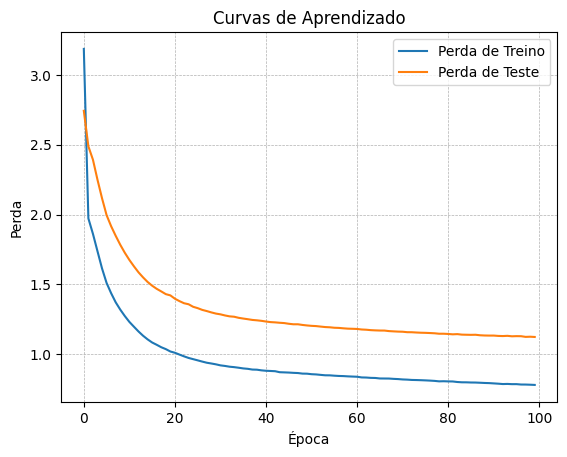

In [51]:
# Plota as curvas de aprendizado de treino e teste usando matplotlib
plt.plot(train_losses, label='Perda de Treino')
plt.plot(test_losses, label='Perda de Teste')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.title('Curvas de Aprendizado')

# Adiciona uma grade ao gráfico
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.legend()
plt.show()

**Expected result**

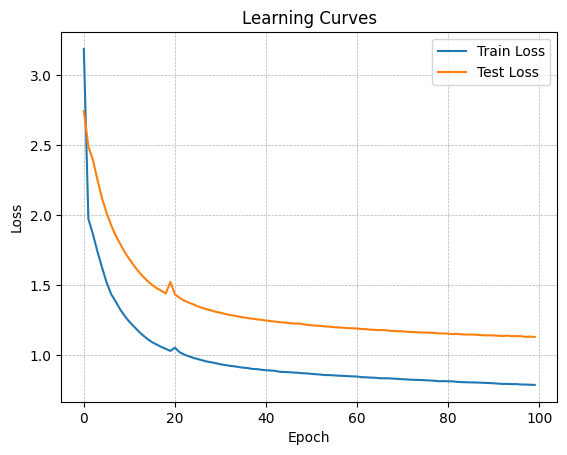

## **Parte 4: Amostragem a partir do Modelo de Linguagem**

Na quarta e última parte, você usará o **modelo de linguagem treinado** para **gerar novos nomes de dinossauros**.

---

### **Para gerar nomes:**

1. **Comece com uma string inicial (prime string)** e alimente-a no modelo caractere por caractere,  
   usando a função `encode` da classe `DinosDataset` para criar vetores *one-hot*.

2. **Para a geração de caracteres:**
   - Aplique [`torch.nn.functional.softmax`](https://pytorch.org/docs/stable/generated/torch.nn.functional.softmax.html)  
     na saída do modelo para obter as **probabilidades dos próximos caracteres**.  
   - Use [`torch.multinomial`](https://pytorch.org/docs/stable/generated/torch.multinomial.html)  
     para **amostrar o índice do próximo caractere** com base nessas probabilidades.  
   - Converta o índice de volta para um caractere usando a função `decode`.

3. **Loop de geração:**
   - Continue gerando caracteres até encontrar o **token de fim `"]"`**.  
   - A cada caractere gerado, **alimente-o novamente como entrada** para prever o próximo.  
   - Armazene todos os caracteres gerados para **formar o nome final**.

---

### **Parâmetros a utilizar:**
- **Prime string:** sequência inicial usada para iniciar a geração.  
- **Temperature:** controla o grau de aleatoriedade na geração (se implementado).  
- O modelo deve estar em **modo de avaliação** durante o processo de geração.

In [52]:
def generate(model, text_dataset, prime="["):
  """
  Gera um nome de dinossauro usando um modelo treinado e uma sequência inicial (prime).

  Argumentos:
  - model (torch.nn.Module): Modelo de linguagem treinado usado para gerar nomes.
  - text_dataset (torch.utils.data.Dataset): Dataset de linguagem usado para codificar/decodificar nomes de dinossauros.
  - prime (str): Sequência inicial usada para começar o processo de geração.

  Retorna:
  - dinosaur_name (str): Um nome de dinossauro gerado pelo modelo.
  """
  model.eval()  # Coloca o modelo em modo de avaliação
  char_2_idx = DinosDataset.encode('text_dataset')
  idx_2_char = DinosDataset.decode('text_dataset')

  input_prime = [char_2_idx[char] for char in prime]
  input_prime = torch.tensor(input_prime).unsqueeze(1)

  generated_name = prime
def generate(model, text_dataset, prime="[", max_len=30):
  """
  Gera um nome de dinossauro usando um modelo treinado e uma sequência inicial (prime).

  Argumentos:
  - model (torch.nn.Module): Modelo de linguagem treinado usado para gerar nomes.
  - text_dataset (torch.utils.data.Dataset): Dataset de linguagem usado para codificar/decodificar nomes de dinossauros.
  - prime (str): Sequência inicial usada para começar o processo de geração.
  - max_len (int): Comprimento máximo do nome gerado para evitar loops infinitos.

  Retorna:
  - dinosaur_name (str): Um nome de dinossauro gerado pelo modelo.
  """
  model.eval()  # Coloca o modelo em modo de avaliação

  # Acessa os mapeamentos de char para índice e de índice para char do objeto text_dataset
  char_2_idx = text_dataset.ch2ix
  idx_2_char = text_dataset.ix2ch
  vocab_size = text_dataset.vocab_size # Necessário para o formato one-hot

  generated_name = prime
  hidden = None  # Estado oculto inicial

  with torch.no_grad():
    # Processa a string inicial (prime) para aquecer o estado oculto
    # Cada caractere da 'prime' é passado individualmente para o modelo
    for char in prime:
        char_idx = char_2_idx[char]
        # Converte o índice do caractere para um vetor one-hot e adiciona as dimensões de batch e sequência
        # input_tensor deve ter o formato (batch_size=1, seq_len=1, vocab_size)
        input_tensor = text_dataset.one_hot_encode(char_idx).unsqueeze(0).unsqueeze(0)
        output, hidden = model(input_tensor, hidden)

    # Inicia a geração de novos caracteres
    # O 'output' do último caractere processado da 'prime' é usado para prever o próximo caractere
    # O modelo retorna (batch_size, seq_len, vocab_size). Para um único passo de tempo e batch, é (1, 1, vocab_size).
    # Squeeze para (1, vocab_size) para o softmax
    output_for_softmax = output.squeeze(1) # output agora tem o formato (1, vocab_size)

    for _ in range(max_len): # Limita o comprimento do nome gerado
        # Aplica softmax para obter probabilidades e amostra o próximo caractere
        probs = torch.nn.functional.softmax(output_for_softmax, dim=1)
        next_char_idx = torch.multinomial(probs, num_samples=1).item()

        next_char = idx_2_char[next_char_idx]
        generated_name += next_char

        if next_char == ']': # Para a geração se o token de fim for encontrado
            break

        # Prepara a entrada para o próximo passo do modelo: o caractere recém-gerado
        input_tensor = text_dataset.one_hot_encode(next_char_idx).unsqueeze(0).unsqueeze(0)
        output, hidden = model(input_tensor, hidden)
        output_for_softmax = output.squeeze(1) # Atualiza o output para o próximo softmax

  return generated_name


  ######################################
  # SEU CÓDIGO AQUI (remova o pass)
  ######################################

In [53]:
torch.manual_seed(1)

# Carrega o modelo treinado
model = DinosRNNLanguageModel(train_dataset.vocab_size, hidden_size=50)
model.load_state_dict(torch.load('dinos_net.pth'))

# Gera e imprime 10 nomes de dinossauros
n_dinosaurs = 10
for i in range(n_dinosaurs):
  p = generate(model, train_dataset)
  print(p)

[Hatesaurus]
[Chaglingoator]
[Bahkehylovema]
[Zakatophosuchus]
[Gyrdondon]
[Vazhyosaurus]
[Stidodyx]
[Dalceltasbus]
[Raharmiansaurus]
[Gagzoceratos]


**Expected result**:
<table>
    <tr>
        <td> [Patesausaurus]</td>
    </tr>
    <tr>
        <td> [Olingoatordinus]</td>
    </tr>
    <tr>
        <td> [Chalorosaurus]</td>
    </tr>
    <tr>
        <td> [Caceosaurus]</td>
    </tr>
    <tr>
        <td> [Propnosaurus]</td>
    </tr>
    <tr>
        <td> [Mococylisaurus]</td>
    </tr>
    <tr>
        <td> [Hinfwaceptosbus]</td>
    </tr>     
    <tr>
        <td> [Raharmiansaurus]</td>
    </tr>
    <tr>
        <td> [Gagzoceratos]</td>
    </tr>   
    <tr>
        <td> [Liatausaurus]</td>
    </tr>                    
</table>

🎉 **Parabéns!**  
Seu modelo de linguagem está pronto para **gerar novos dinossauros!** 🦖

## **Parte 6: Gere o seu próprio Dinossauro**

Use a função `generate` para criar uma lista de **nomes de dinossauros**.  
Quando encontrar um nome que você goste, use um **gerador de imagens** (por exemplo, o ChatGPT) para **ilustrar o seu novo dinossauro**. 🦕

💡 **Dica:**  
Use um prompt como:  
> “Gere um dinossauro fictício chamado [NOME_DO_DINOSSAURO].”

Por exemplo, abaixo está uma imagem gerada pelo ChatGPT para o dinossauro chamado **Propnosaurus**:


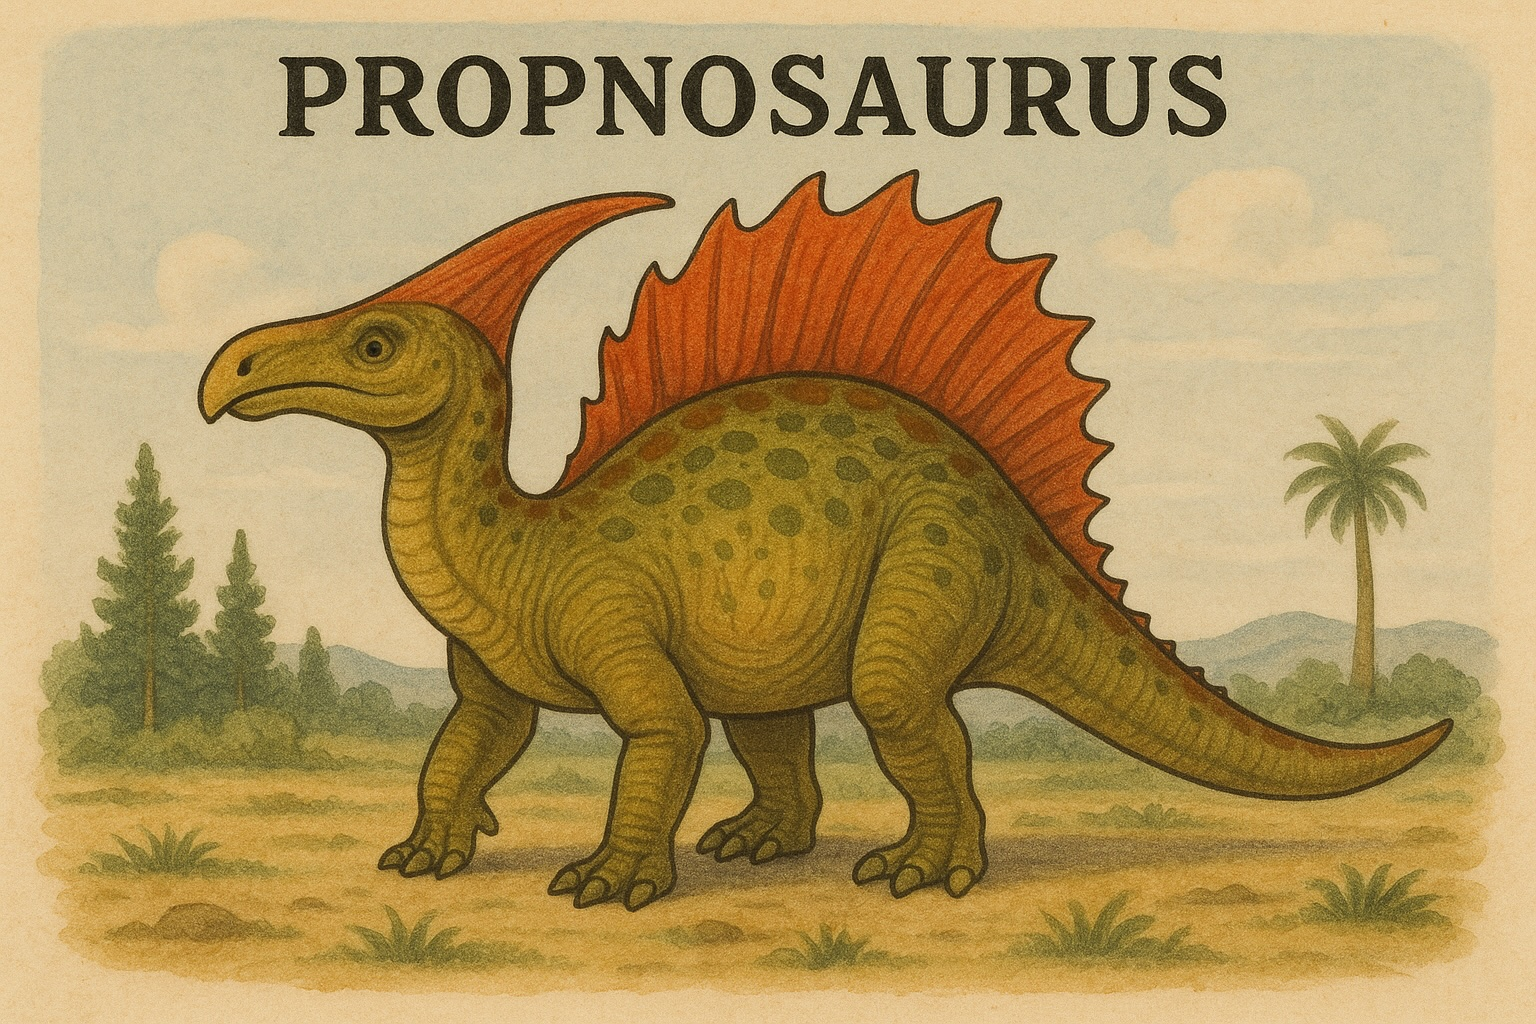

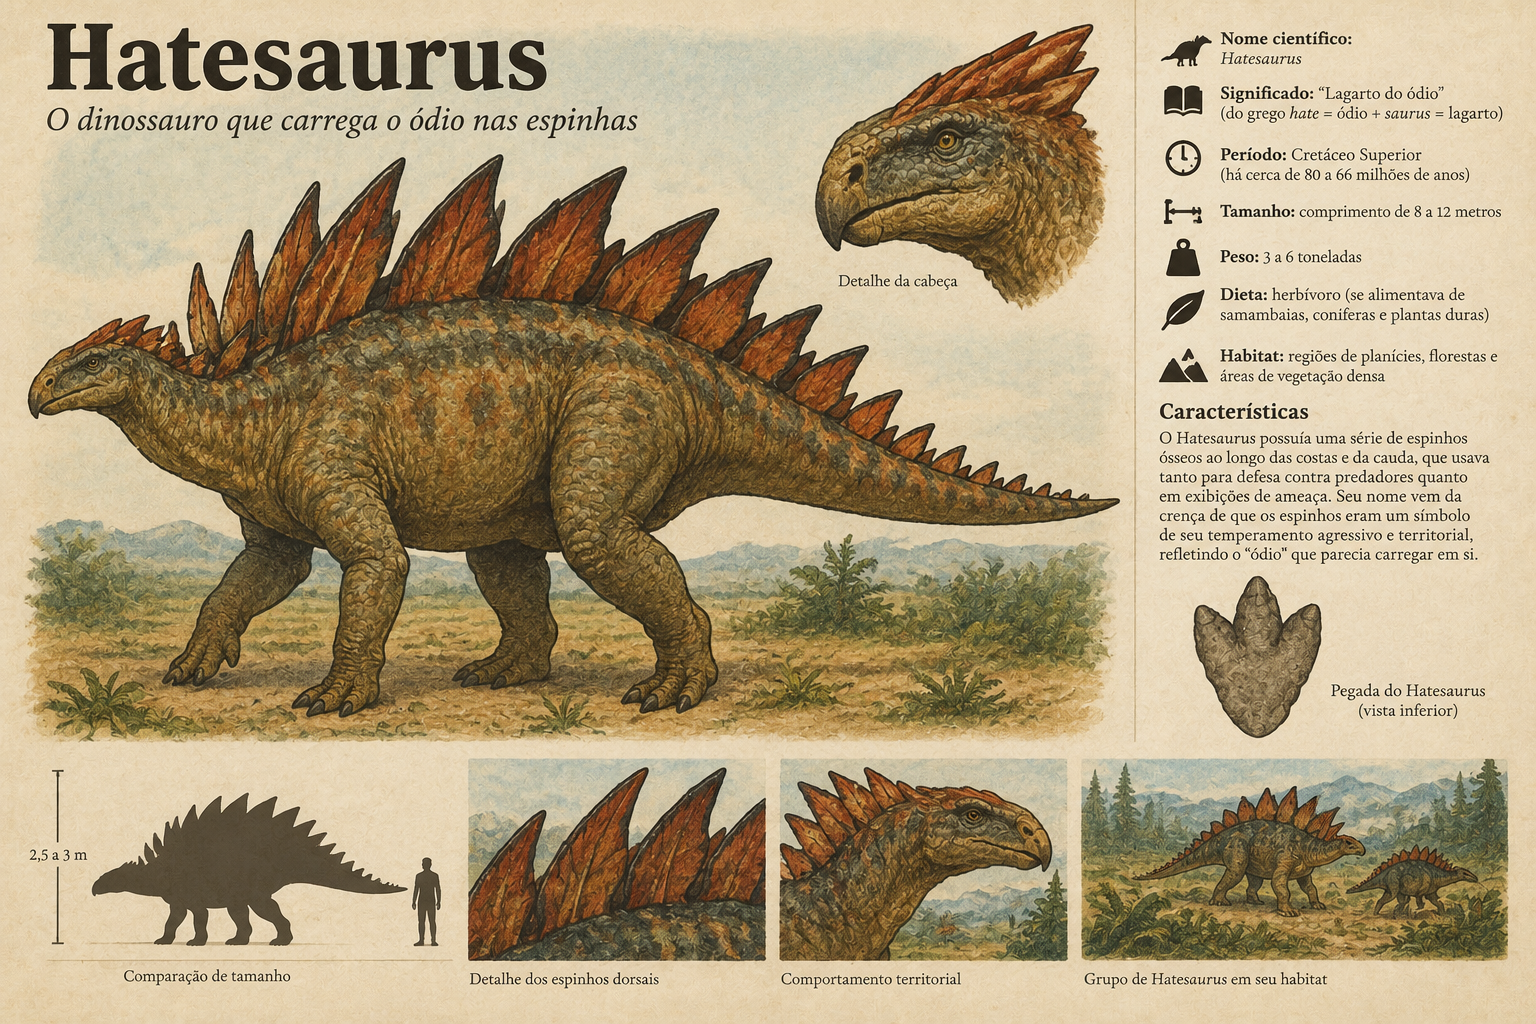